# Telco Customer Churn Prediction Engine
**Goal:** Build a production-ready ensemble system to predict customer attrition.

### Key Implementation Details:
1. **Feature Engineering:** Automated a pipeline for `Total_Services` count and `Monthly_Diff` to identify price-sensitive churners.
2. **Modeling:** Initially trained using separeate models(random forest,gradient boosting,xg boost) and in next step ** Implemented a Soft-Voting Ensemble** (Random Forest + XGBoost) to maximize model stability.
3. **MLOps Architecture:** Separated preprocessing logic for training/serving parity.
4. **Deployment:** Wrapped in **FastAPI** and **Docker** for serverless scaling on Cloud Run.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [43]:
from google.colab import drive


drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [44]:
#DATA UPLOAD
dir = '/content/drive/My Drive/telco_churn/'
dataset_url = dir+'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(dataset_url)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [45]:
# Data Preprocessing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop('customerID', axis=1, inplace=True)

In [46]:
# Encode Target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [47]:
# One-Hot Encoding for categorical features
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [48]:
#TRAIN/TEST SPLIT
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
#model_training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [50]:
#evaluation
y_pred = model.predict(X_test)
print("\n" + "="*30)
print(f"MODEL ACCURACY: {accuracy_score(y_test, y_pred):.2%}")
print("="*30)
print("\nCLASSIFICATION REPORT:\n", classification_report(y_test, y_pred))


MODEL ACCURACY: 78.92%

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



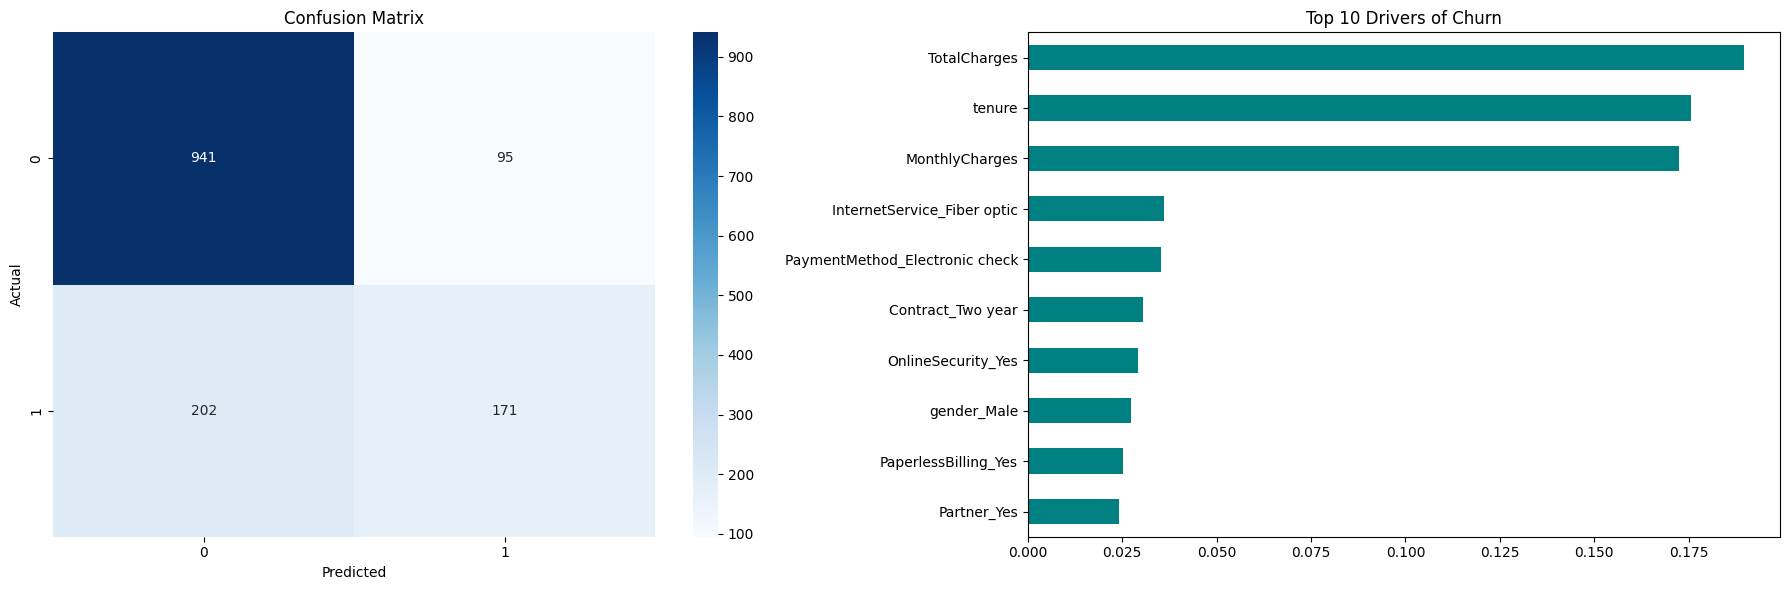

In [51]:
# Confusion Matrix
fig, ax = plt.subplots(1,2, figsize=(18, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_ylabel('Actual')
ax[0].set_xlabel('Predicted')
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).nlargest(10)
importances.sort_values().plot(kind='barh', color='teal', ax=ax[1])
ax[1].set_title('Top 10 Drivers of Churn')

plt.tight_layout()
plt.show()

In [52]:
#Gradient Boosting model
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

Gradient Boosting Accuracy: 80.91%
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



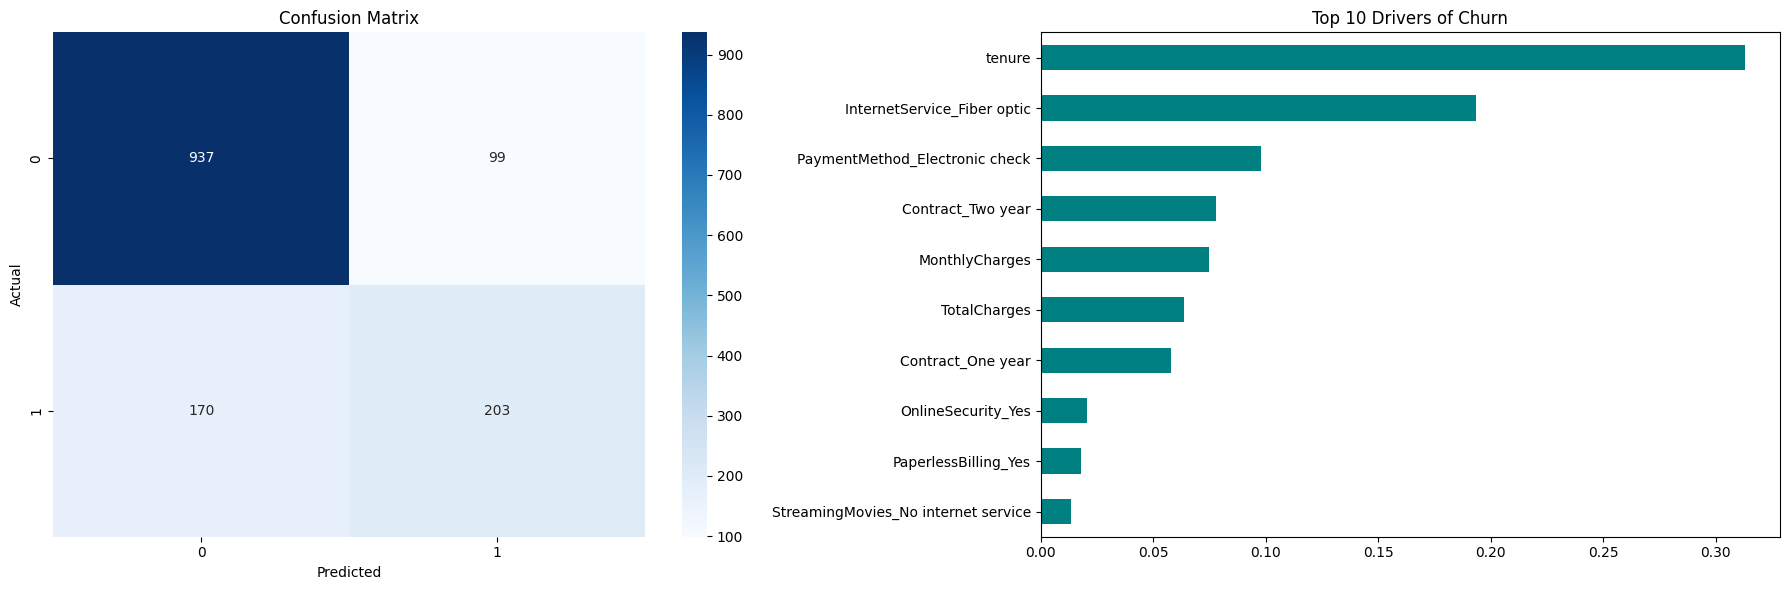

In [53]:
# gb model Confusion Matrix
fig, ax = plt.subplots(1,2, figsize=(18, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_ylabel('Actual')
ax[0].set_xlabel('Predicted')
# Feature Importance
importances = pd.Series(gb_model.feature_importances_, index=X.columns).nlargest(10)
importances.sort_values().plot(kind='barh', color='teal', ax=ax[1])
ax[1].set_title('Top 10 Drivers of Churn')

plt.tight_layout()
plt.show()

In [54]:
#xg boost model
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))


XGBoost Accuracy: 81.33%
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:39:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


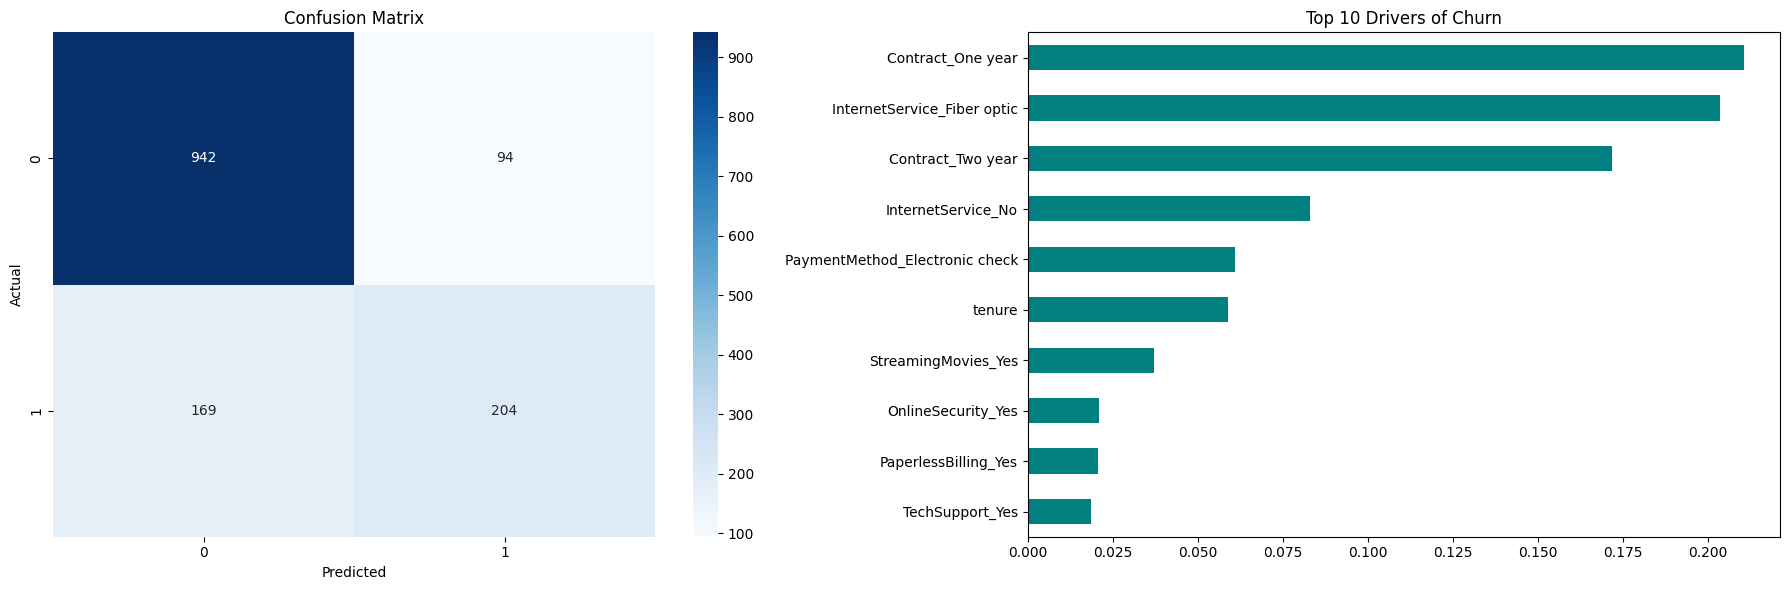

In [55]:
# gb model Confusion Matrix
fig, ax = plt.subplots(1,2, figsize=(18, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_ylabel('Actual')
ax[0].set_xlabel('Predicted')
# Feature Importance
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).nlargest(10)
importances.sort_values().plot(kind='barh', color='teal', ax=ax[1])
ax[1].set_title('Top 10 Drivers of Churn')

plt.tight_layout()
plt.show()

In [56]:
#hyperparamter_tuning for accuracy improvement

In [57]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
models_to_tune = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 150],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 4]
        }
    },
    'XG Boost': {
        'model': xgb.XGBClassifier(random_state=42),
        'params': {
            'max_iter': [100, 150],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]
        }
    }
}

best_models = {}

for name, mp in models_to_tune.items():
    print(f"--- Tuning {name} ---")
    grid = GridSearchCV(mp['model'], mp['params'], cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Best Params: {grid.best_params_}")
    print(f"Best CV Accuracy: {grid.best_score_:.4f}\n")


#FINAL EVALUATION & COMPARISON

results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Test Accuracy': acc})

    print(f"\n[{name} Classification Report]")
    print(classification_report(y_test, y_pred))

# Display Comparison Table
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
print("\n--- FINAL COMPARISON ---")
print(results_df)

--- Tuning Random Forest ---
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Accuracy: 0.7996

--- Tuning Gradient Boosting ---
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
Best CV Accuracy: 0.8017

--- Tuning XG Boost ---
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100}
Best CV Accuracy: 0.8024


[Random Forest Classification Report]
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.52      0.60       373

    accuracy                           0.82      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.81      0.82      0.81      1409


[Gradient Boosting Classification Report]
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:39:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_iter" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [58]:
best_model_name = results_df.iloc[0]['Model']
final_model = best_models[best_model_name]



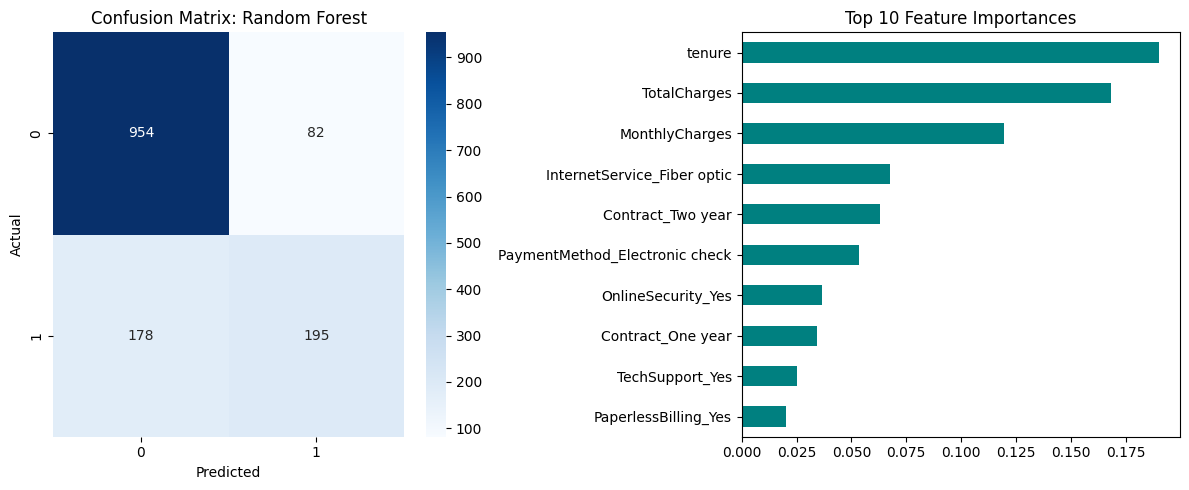

In [59]:
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, final_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Feature Importance (Random Forest & Gradient Boosting only)
if hasattr(final_model, 'feature_importances_'):
    plt.subplot(1, 2, 2)
    feat_importances = pd.Series(final_model.feature_importances_, index=X.columns)
    feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
    plt.title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

Post-Engineering Accuracy: 80.98%
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.51      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



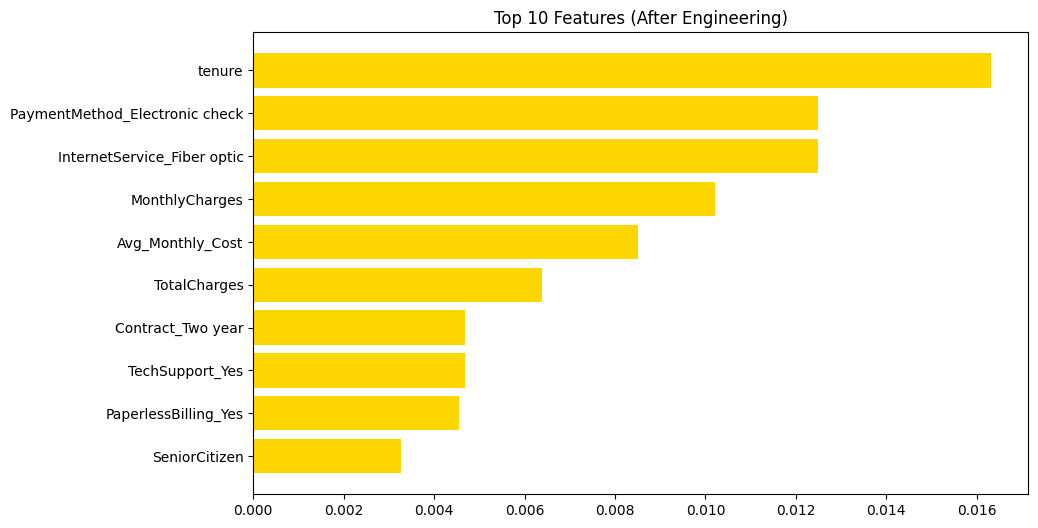

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


#DATA UPLOAD
dir = '/content/drive/My Drive/telco_churn/'
dataset_url = dir+'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(dataset_url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. FEATURE ENGINEERING FUNCTION
def engineer_features(df):
    # Cleaning
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(df['TotalCharges'].median())

    # Feature 1: Total Services Count
    services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['Total_Services'] = (df[services] == 'Yes').sum(axis=1)

    # Feature 2: Tenure Groups
    df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72, 100], labels=['0-1y', '1-2y', '2-4y', '4-6y', '6y+'])

    # Feature 3: Cost Efficiency Metrics
    df['Avg_Monthly_Cost'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
    df['Monthly_Diff'] = df['MonthlyCharges'] - df['Avg_Monthly_Cost']

    # Feature 4: Protection Bundle
    df['Has_Protection'] = ((df['OnlineSecurity'] == 'Yes') | (df['OnlineBackup'] == 'Yes')).astype(int)

    # Feature 5: Media Bundle
    df['Is_Streamer'] = ((df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'Yes')).astype(int)

    return df

# Apply Engineering
df = engineer_features(df)

# 3. PREPARE FOR MODELING
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. TRAIN MODEL (HistGradientBoosting)
model = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=10,min_samples_split=5)
model.fit(X_train, y_train)

# 5. EVALUATE
y_pred = model.predict(X_test)
print(f"Post-Engineering Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

# 6. VISUALIZE TOP 10 FEATURES
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(model, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()[-10:]

plt.figure(figsize=(10,6))
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx], color='gold')
plt.title('Top 10 Features (After Engineering)')
plt.show()

Post-Engineering Accuracy: 80.77%
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



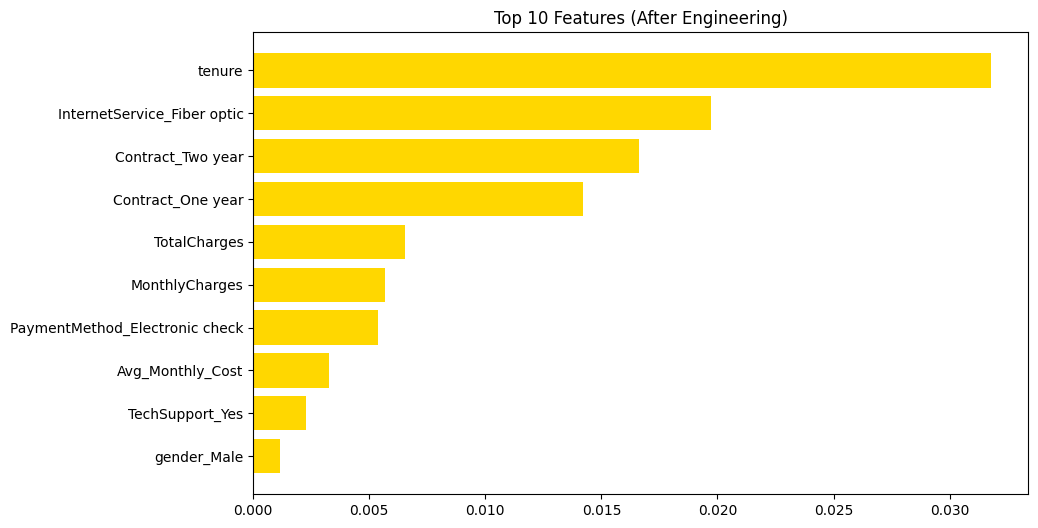

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


#DATA UPLOAD
dir = '/content/drive/My Drive/telco_churn/'
dataset_url = dir+'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(dataset_url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. FEATURE ENGINEERING FUNCTION
def engineer_features(df):
    # Cleaning
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(df['TotalCharges'].median())

    # Feature 1: Total Services Count
    services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['Total_Services'] = (df[services] == 'Yes').sum(axis=1)

    # Feature 2: Tenure Groups
    df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72, 100], labels=['0-1y', '1-2y', '2-4y', '4-6y', '6y+'])

    # Feature 3: Cost Efficiency Metrics
    df['Avg_Monthly_Cost'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
    df['Monthly_Diff'] = df['MonthlyCharges'] - df['Avg_Monthly_Cost']

    # Feature 4: Protection Bundle
    df['Has_Protection'] = ((df['OnlineSecurity'] == 'Yes') | (df['OnlineBackup'] == 'Yes')).astype(int)

    # Feature 5: Media Bundle
    df['Is_Streamer'] = ((df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'Yes')).astype(int)

    return df

# Apply Engineering
df = engineer_features(df)

# 3. PREPARE FOR MODELING
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. TRAIN MODEL (HistGradientBoosting)
model = HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5. EVALUATE
y_pred = model.predict(X_test)
print(f"Post-Engineering Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

# 6. VISUALIZE TOP 10 FEATURES
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(model, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()[-10:]

plt.figure(figsize=(10,6))
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx], color='gold')
plt.title('Top 10 Features (After Engineering)')
plt.show()

In [62]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# 1. Define the two Base Models
# Your tuned Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    min_samples_split=5
)

# Tuned XGBoost Model
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    eval_metric='logloss',
    random_state=42
)

# 2. Create the Voting Classifier
# "soft" means they average their predicted probabilities
voting_model = VotingClassifier(
    estimators=[
        ('Random_Forest', rf_model),
        ('XGBoost', xgb_model)
    ],
    voting='soft'
)

# 3. Train the Ensemble Model
print("Training Voting Classifier...")
voting_model.fit(X_train, y_train)

# 4. Evaluate the Results
y_pred_voting = voting_model.predict(X_test)

print(f"\n Voting Classifier Accuracy: {accuracy_score(y_test, y_pred_voting):.2%}")
print("\n Detailed Classification Report ---")
print(classification_report(y_test, y_pred_voting))

# Optional: To see how they compare directly
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
print(f"Individual RF Accuracy: {accuracy_score(y_test, rf_model.predict(X_test)):.2%}")
print(f"Individual XGB Accuracy: {accuracy_score(y_test, xgb_model.predict(X_test)):.2%}")

Training Voting Classifier...

 Voting Classifier Accuracy: 81.83%

 Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1036
           1       0.70      0.55      0.61       373

    accuracy                           0.82      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.82      0.81      1409

Individual RF Accuracy: 80.98%
Individual XGB Accuracy: 81.41%


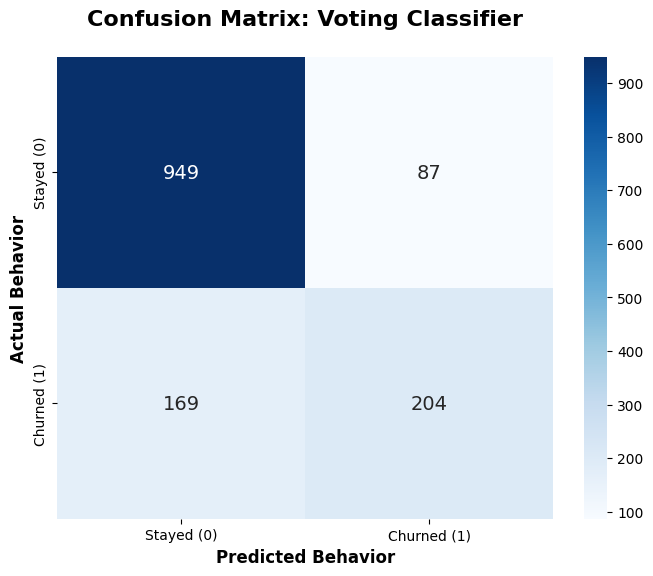



Calculating Feature Importance for the Ensemble (This takes a few seconds)...


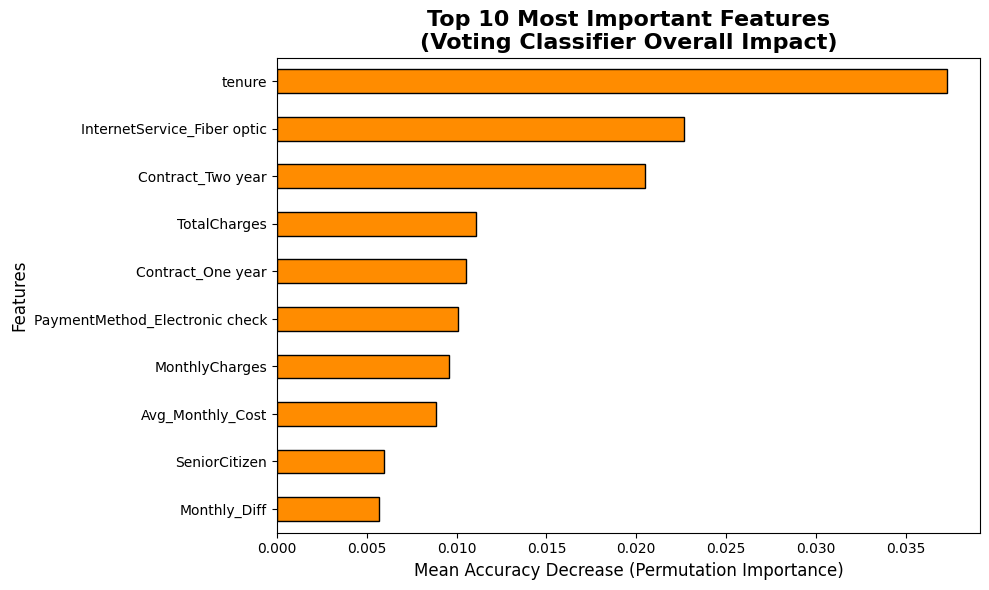

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance

plt.figure(figsize=(8, 6))

# Calculate confusion matrix using the voting classifier predictions
cm = confusion_matrix(y_test, y_pred_voting)

# Create a beautiful heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed (0)', 'Churned (1)'],
            yticklabels=['Stayed (0)', 'Churned (1)'],
            annot_kws={"size": 14})

plt.title('Confusion Matrix: Voting Classifier\n', fontsize=16, fontweight='bold')
plt.ylabel('Actual Behavior', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Behavior', fontsize=12, fontweight='bold')
plt.show()

print("\n" + "="*50 + "\n")


# Calculate Permutation Importance on the Voting Classifier
perm_importance = permutation_importance(
    voting_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

feature_importance_df = pd.Series(perm_importance.importances_mean, index=X.columns)
top_10_features = feature_importance_df.nlargest(10).sort_values(ascending=True)

# Plot as a horizontal bar chart
plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh', color='darkorange', edgecolor='black')

plt.title('Top 10 Most Important Features\n(Voting Classifier Overall Impact)', fontsize=16, fontweight='bold')
plt.xlabel('Mean Accuracy Decrease (Permutation Importance)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

Combining Random Forest and XGBoost reduced variance and captured more complex churn patterns

Saving the model Using Joblib


In [65]:
import joblib
import os


joblib.dump(voting_model, dir+'voting_model.joblib')

model_columns = X.columns.tolist()
joblib.dump(model_columns, dir+'model_columns.joblib')


['/content/drive/My Drive/telco_churn/model_columns.joblib']